In [1]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import joblib
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter
import helpers
import importlib
importlib.reload(helpers)
from helpers import make_splits_by_is_test_or_date, smape, setup_matplotlib, COLORS
import json
try:
    from sklearn.metrics import root_mean_squared_error
    _HAS_RMSE = True
except Exception: # older scikit-learn
    from sklearn.metrics import mean_squared_error
    _HAS_RMSE = False

# Optional for RC baseline
try:
    import statsmodels.api as sm
except Exception:
    sm = None
from sklearn.ensemble import RandomForestRegressor
import os
from features import FEATURES_TIN_ON

def format_time_axis(ax):
    loc = AutoDateLocator()
    fmt = ConciseDateFormatter(loc)
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(fmt)
    ax.minorticks_on()
    ax.grid(True, which="minor", alpha=0.12)

def print_metrics_table(metrics_dict):
    dfm = pd.DataFrame({
        "Metric": ["RMSE", "MAE", "R²", "sMAPE (%)"],
        "Value": [metrics_dict["rmse"], metrics_dict["mae"], metrics_dict["r2"], metrics_dict["smape"]]
    })
    dfm["Value"] = dfm["Value"].map(lambda v: f"{v:,.4f}")
    bar = "="*47
    print("\n" + bar)
    print(" Performance Metrics".center(47, " "))
    print(bar)
    print(dfm.to_string(index=False))
    print(bar + "\n")
    return dfm

def evaluate_and_plot(y_true, y_pred, times, outdir, ylabel="Temperature (°C)", prefix="rf", start_idx=None, end_idx=None, n_skip=6, n_plot=192, title_prefix="Tin when HVAC is ON"):
    # os.makedirs(outdir, exist_ok=True)
    setup_matplotlib()

    # --- metrics ---
    rmse = root_mean_squared_error(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    smp  = smape(y_true, y_pred)
    metrics = {"rmse": rmse, "mae": mae, "r2": r2, "smape": smp}

    results = pd.DataFrame({
        "y_true": np.asarray(y_true, dtype=float),
        "y_pred": np.asarray(y_pred, dtype=float)
    }, index=pd.to_datetime(times)).sort_index()
    residuals = results["y_pred"] - results["y_true"]

    # ------------- (1) time-series plot (zoom on a neat window) -------------
    if start_idx is not None and end_idx is not None:
        seg = results.iloc[start_idx:end_idx]
        window_note = f"Custom window [{start_idx}:{end_idx}] → {len(seg)} points"
    else:
        N_plot = min(n_plot, max(0, len(results) - n_skip)) if len(results) > n_skip else len(results)
        seg = results.iloc[n_skip:n_skip + N_plot] if N_plot > 0 else results
        window_note = f"{len(seg)} points (skip {n_skip})"

    fig, ax = plt.subplots(figsize=(13.5, 4.9))
    ax.plot(seg.index, seg["y_true"], lw=2.5, label="True", color="#1f77b4")
    ax.plot(seg.index, seg["y_pred"], lw=2.5,  ls=(0, (5, 2)), label="Predicted", color="#FF7F0E", alpha=0.9)
    ax.set_title(f"{title_prefix} — {window_note}", pad=10)
    ax.set_ylabel(ylabel)
    format_time_axis(ax)
    leg = ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), framealpha=0.9, borderpad=0.8)
    for line in leg.get_lines(): line.set_linewidth(3)
    fig.tight_layout()
    plt.show()

    # ------------- (2) parity plot -------------
    fig, ax = plt.subplots(figsize=(6.2, 6.2))
    ax.scatter(results["y_true"], results["y_pred"], s=18, alpha=0.7,
               edgecolors="none", color=COLORS.get("pred", "#f59e0b"))
    mn = float(np.nanmin([results["y_true"].min(), results["y_pred"].min()]))
    mx = float(np.nanmax([results["y_true"].max(), results["y_pred"].max()]))
    ax.plot([mn, mx], [mn, mx], lw=2.0, color=COLORS.get("eqline", "#64748b"))
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.set_title("Parity (ŷ vs y)")
    ax.grid(True, alpha=0.2)
    ax.minorticks_on()
    fig.tight_layout()
    plt.show()

    return metrics


def run_rf_hvac_on(
    folder_path: str,
    hvac_col: str = "hvac_mode",
    save_root: str = "models",
    plot_window: tuple[int, int] = (50, 236)
):
    dfs = []

    for filename in os.listdir(folder_path):
        if filename.endswith('with_comfort.csv'):
            file_path = os.path.join(folder_path, filename)
            df = pd.read_csv(file_path)
        
            df['timestamp'] = pd.to_datetime(df['timestamps'])
            
            df.drop(columns=['timestamps'], inplace=True)
            df.set_index('timestamp', inplace=True)
            df.sort_index(inplace=True)
            dfs.append(df)

    for index, df in enumerate(dfs):
        feature_cols = FEATURES_TIN_ON
        missing = [c for c in feature_cols if c not in df.columns]
        assert not missing, f"[df_{index}] Missing required features: {missing}. Make sure features.py created them."
        train_idx, val_idx, test_idx = make_splits_by_is_test_or_date(df)

        df_train = df.iloc[train_idx]
        df_val   = df.iloc[val_idx]
        df_test  = df.iloc[test_idx]

        def _xy(frame: pd.DataFrame):
            X = frame[feature_cols]
            y = frame["Tin_target"]
            m = (~X.isna().any(axis=1)) & y.notna()
            return X.loc[m], y.loc[m]
        
        param_grid = {
            "n_estimators": [120, 160, 200],
            "max_depth": [8, 10, 12, 14],
            "min_samples_leaf": [3, 5, 7, 9],
            "min_samples_split": [2, 5, 10],
        }
        tscv = TimeSeriesSplit(n_splits=5)

        # out dir + where we’ll save
        save_dir = os.path.join(save_root, f"df_{index}")
        os.makedirs(save_dir, exist_ok=True)
        
        models = {}
        level_metrics = {}
        for level in (1, 2):
            # filter ON rows for this level
            tr = df_train[df_train[hvac_col] == level]
            vl = df_val[df_val[hvac_col] == level]
            te = df_test[df_test[hvac_col] == level]

            if len(tr) < 300:
                print(f"[df_{index}] hvac={level}: not enough ON samples ({len(tr)}). Skipping this level.")
                continue

            X_train, y_train = _xy(tr)
            X_val,   y_val   = _xy(vl)
            X_test,  y_test  = _xy(te)
            rf = RandomForestRegressor(random_state=42, n_jobs=-1)
            grid = GridSearchCV(
                rf,
                param_grid,
                cv=tscv,
                scoring="neg_mean_absolute_error",
                verbose=0,
                n_jobs=-1,
            )
            grid.fit(X_train, y_train)

            best = grid.best_estimator_
            models[level] = best
            joblib.dump(best, os.path.join(save_dir, f"rf_on_{level}.pkl"))
            print(f"[df_{index}] ✓ hvac={level}  Best: {grid.best_params_}  (CV MAE={-grid.best_score_:.3f})")

            # quick validation metrics
            if len(X_val) > 0:
                yvp = best.predict(X_val)
                vmae = mean_absolute_error(y_val, yvp)
                vrmse = root_mean_squared_error(y_val, yvp)
                print(f"           Val hvac={level}: MAE={vmae:.3f}  RMSE={vrmse:.3f}")

            # store test metrics per level (and we’ll also make a combined plot later)
            if len(X_test) > 0:
                ytp = best.predict(X_test)
                level_metrics[level] = {
                    "y_true": y_test,
                    "y_pred": pd.Series(ytp, index=y_test.index),
                }

        # save the feature order (for your forecaster loader)
        with open(os.path.join(save_dir, "rf_on_features.json"), "w") as f:
            json.dump({"features": feature_cols}, f, indent=2)

        print(f"[df_{index}] Saved RF models & features → {save_dir}")

        # ---- Combined ON evaluation (using each level’s model on its rows) ----
        # build a single aligned test series across ON rows
        on_mask_test = df_test[hvac_col].isin([1, 2])
        test_on = df_test.loc[on_mask_test].copy()
        X_all, y_all = _xy(test_on)

        # route each row to its level model
        preds = []
        idxs  = []
        for lvl in (1, 2):
            mdl = models.get(lvl)
            if mdl is None:
                continue
            part = test_on[test_on[hvac_col] == lvl]
            Xa, ya = _xy(part)
            if len(Xa) == 0:
                continue
            pa = mdl.predict(Xa)
            preds.append(pd.Series(pa, index=ya.index))
            idxs.append(ya)

        if preds:
            y_pred_all = pd.concat(preds).sort_index()
            y_true_all = pd.concat(idxs).sort_index()
            # align just in case
            y_true_all = y_true_all.loc[y_pred_all.index]

            print("\n[Combined ON test] metrics:")
            evaluate_and_plot(
                y_true=y_true_all.values,
                y_pred=y_pred_all.values,
                times=y_true_all.index,
                outdir=save_dir,
                ylabel="Indoor Temperature [°C]",
                prefix="rf_on_split",
                start_idx=plot_window[0],
                end_idx=plot_window[1],
                title_prefix="Tin when HVAC is ON (split by level)",
            )
        else:
            print(f"[df_{index}] No ON predictions to evaluate (missing models or data).")

[df_0] ✓ hvac=1  Best: {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 200}  (CV MAE=0.076)
           Val hvac=1: MAE=0.060  RMSE=0.079
[df_0] ✓ hvac=2  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}  (CV MAE=0.080)
           Val hvac=2: MAE=0.102  RMSE=0.141
[df_0] Saved RF models & features → models\df_0

[Combined ON test] metrics:


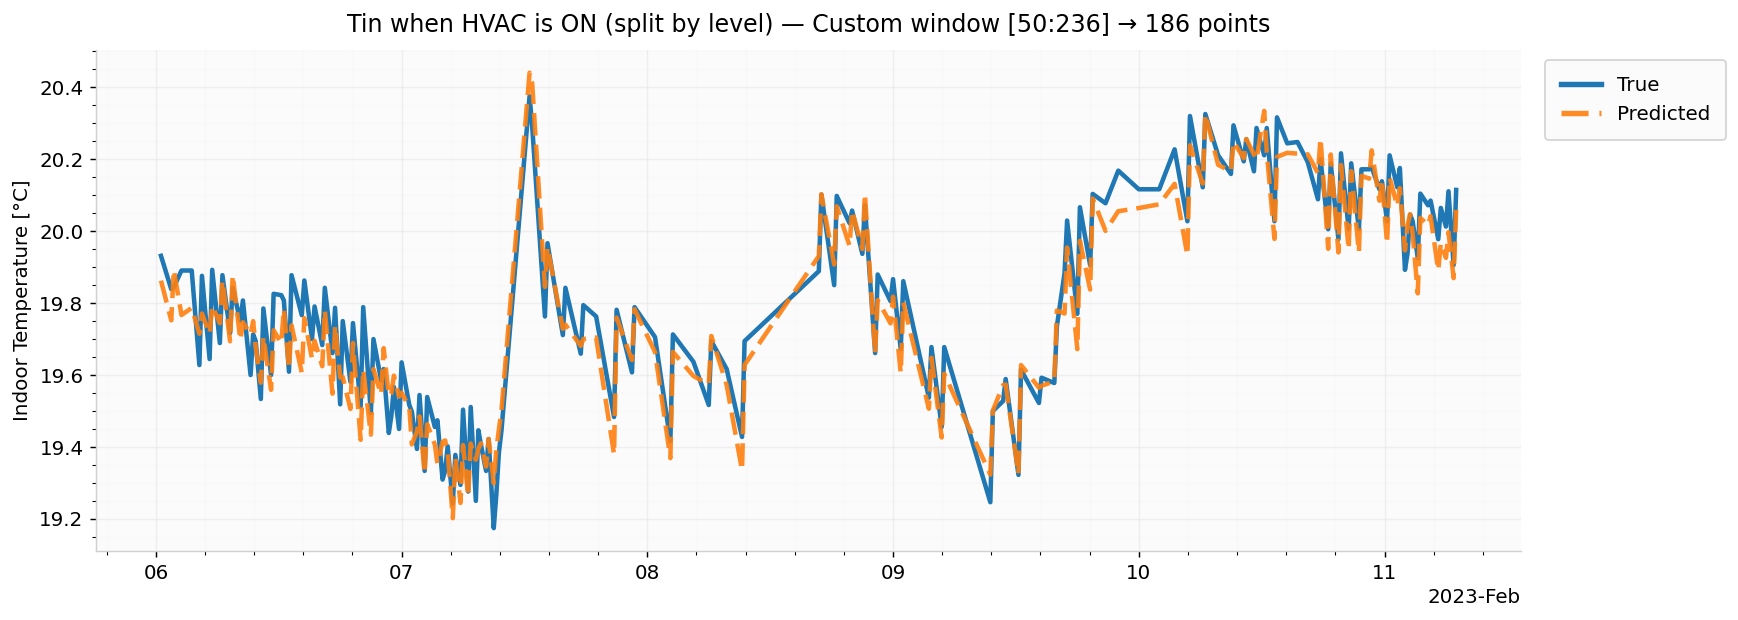

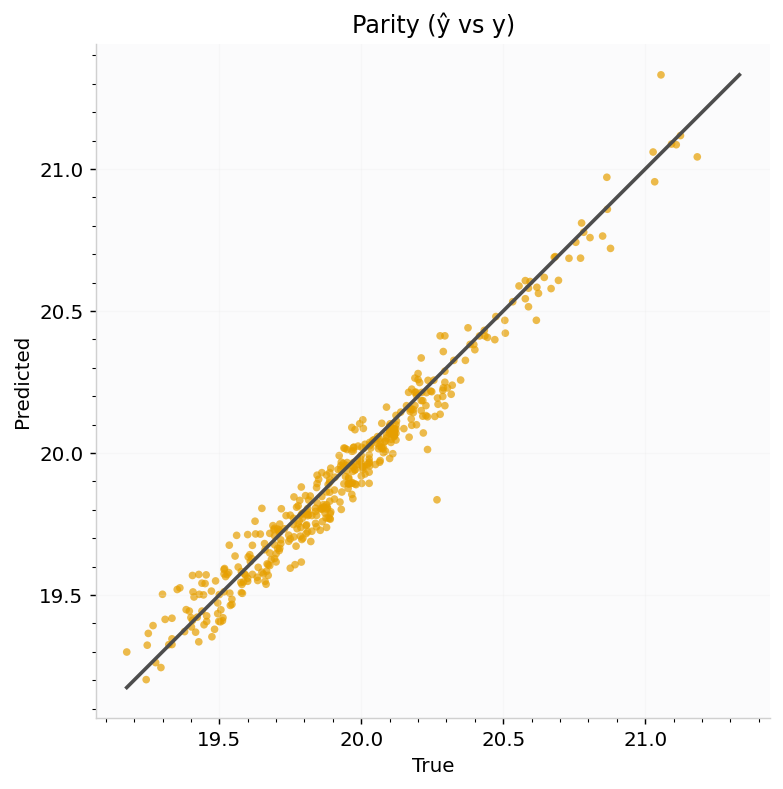

[df_1] ✓ hvac=1  Best: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200}  (CV MAE=0.219)
           Val hvac=1: MAE=0.141  RMSE=0.197
[df_1] ✓ hvac=2  Best: {'max_depth': 14, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 160}  (CV MAE=0.148)
           Val hvac=2: MAE=0.195  RMSE=0.261
[df_1] Saved RF models & features → models\df_1

[Combined ON test] metrics:


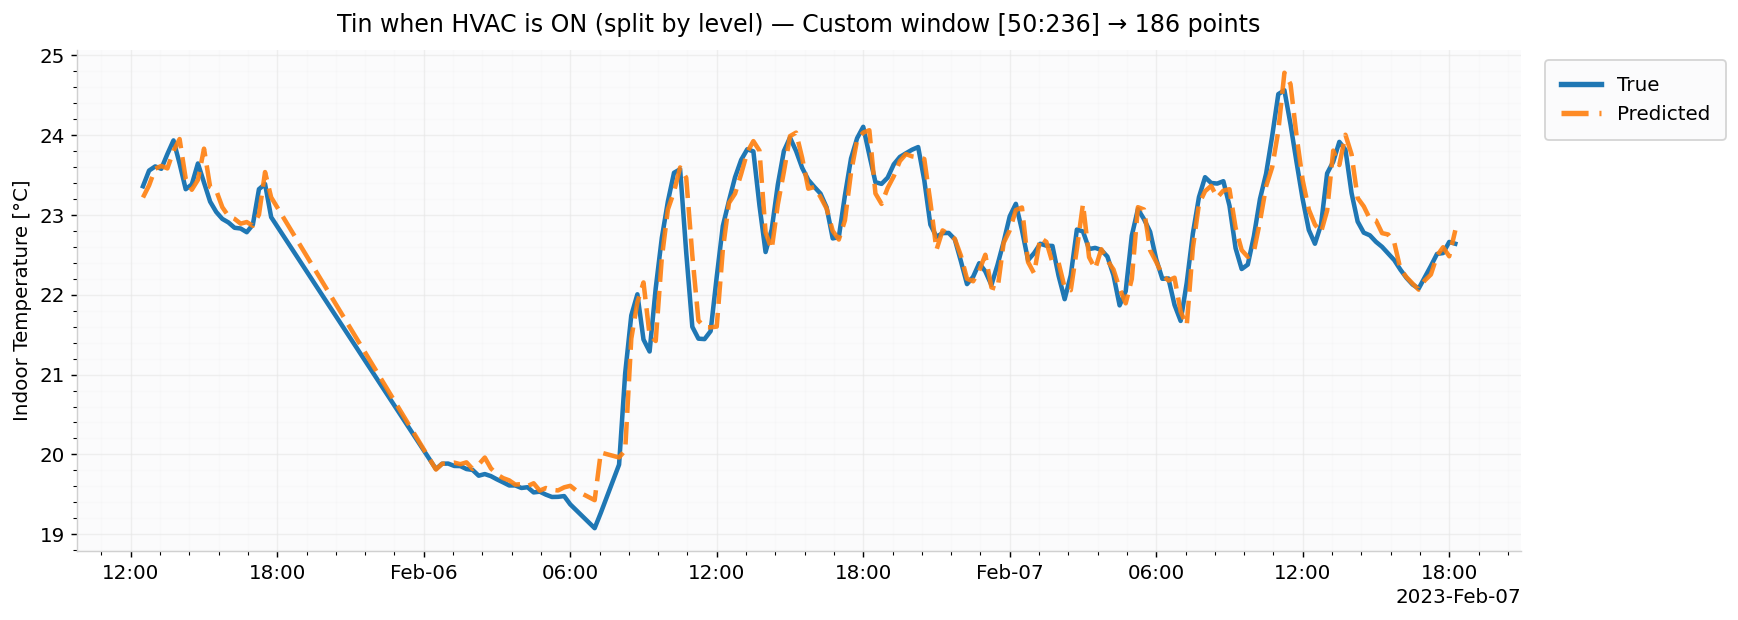

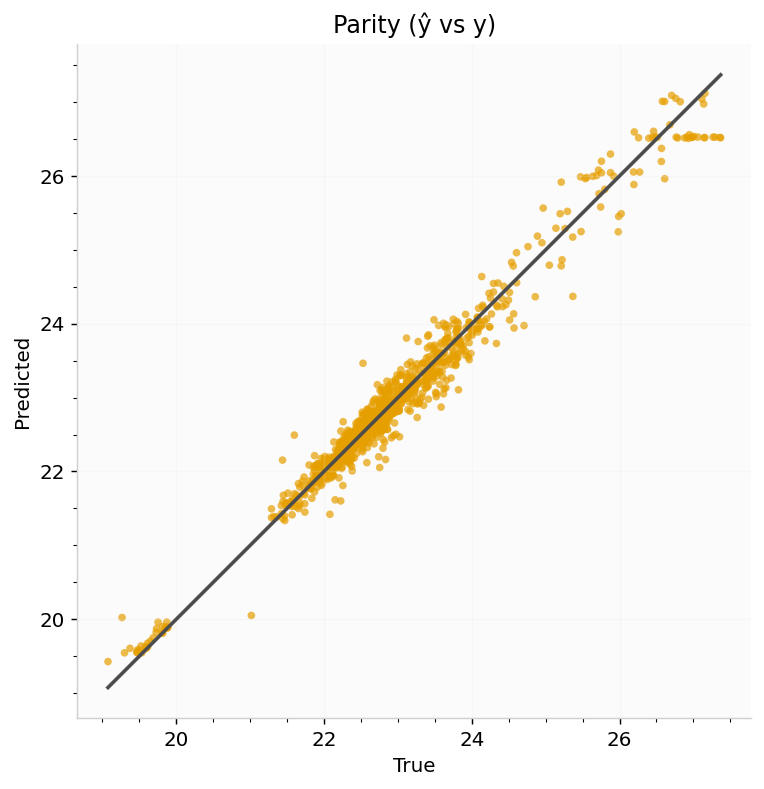

[df_2] ✓ hvac=1  Best: {'max_depth': 12, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 120}  (CV MAE=0.072)
           Val hvac=1: MAE=0.055  RMSE=0.074
[df_2] ✓ hvac=2  Best: {'max_depth': 12, 'min_samples_leaf': 7, 'min_samples_split': 2, 'n_estimators': 200}  (CV MAE=0.079)
           Val hvac=2: MAE=0.080  RMSE=0.109
[df_2] Saved RF models & features → models\df_2

[Combined ON test] metrics:


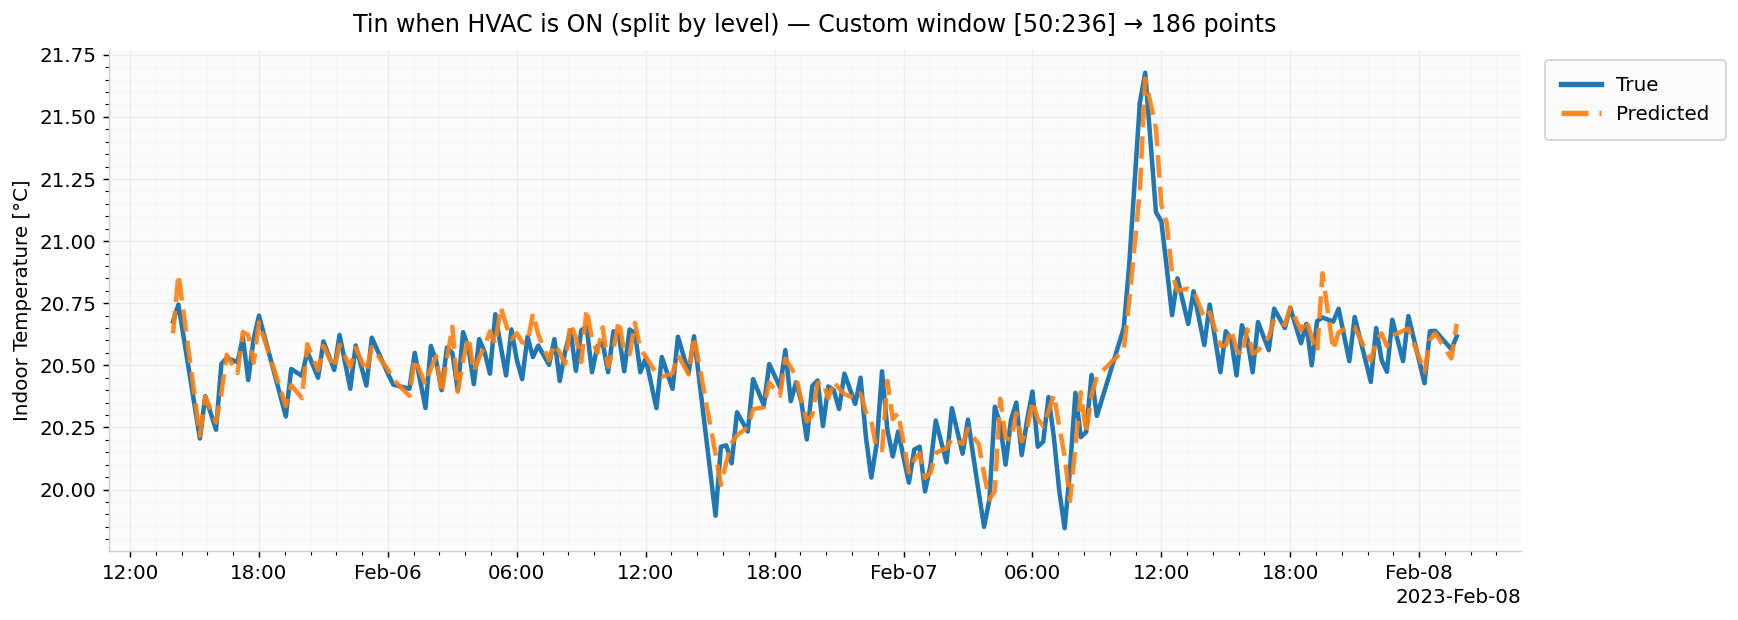

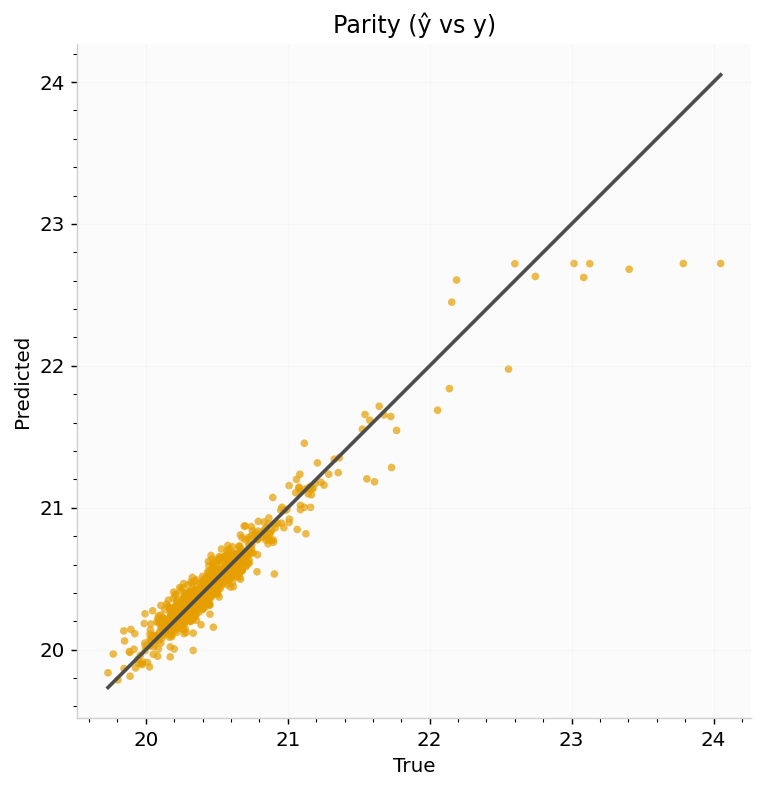

[df_3] ✓ hvac=1  Best: {'max_depth': 12, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 200}  (CV MAE=0.116)
           Val hvac=1: MAE=0.287  RMSE=0.602
[df_3] ✓ hvac=2  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200}  (CV MAE=0.125)
           Val hvac=2: MAE=0.114  RMSE=0.157
[df_3] Saved RF models & features → models\df_3

[Combined ON test] metrics:


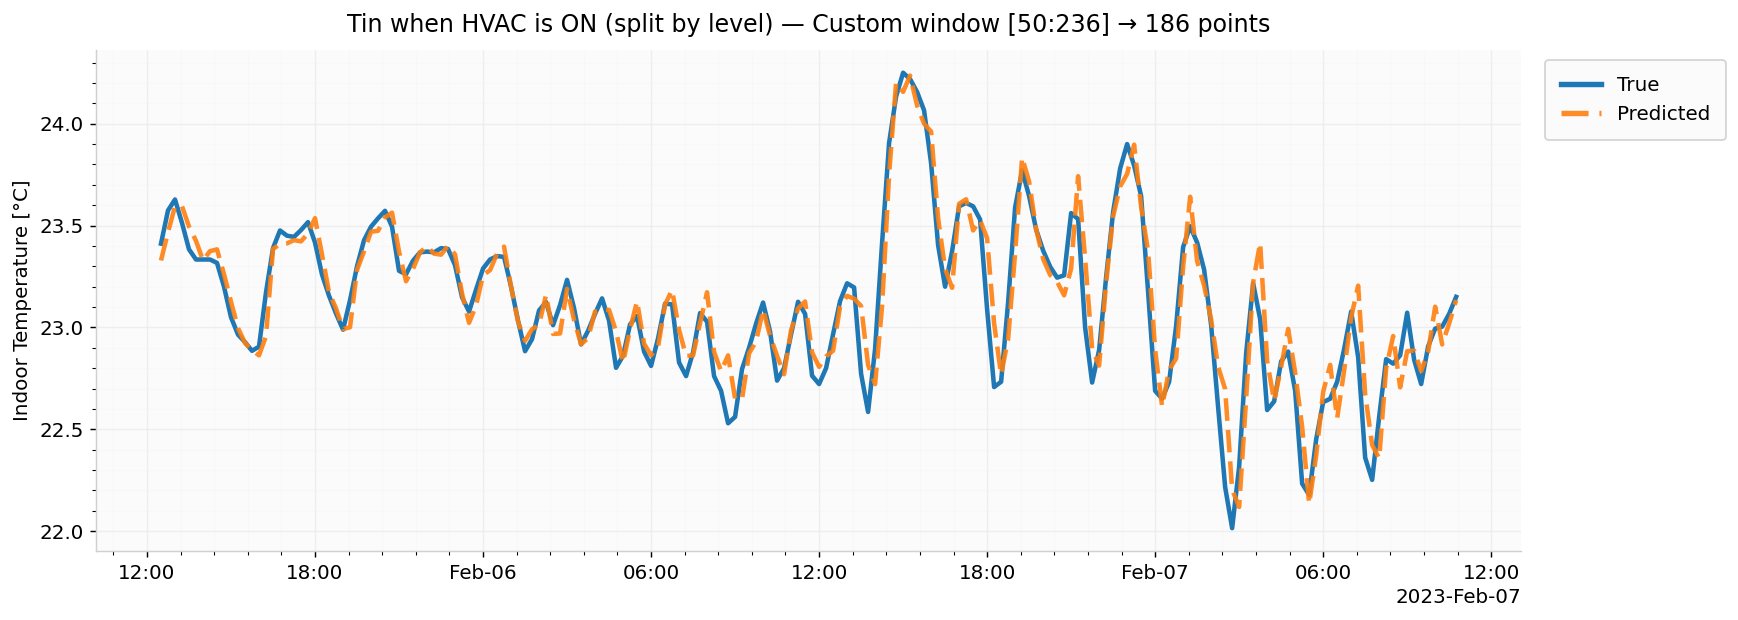

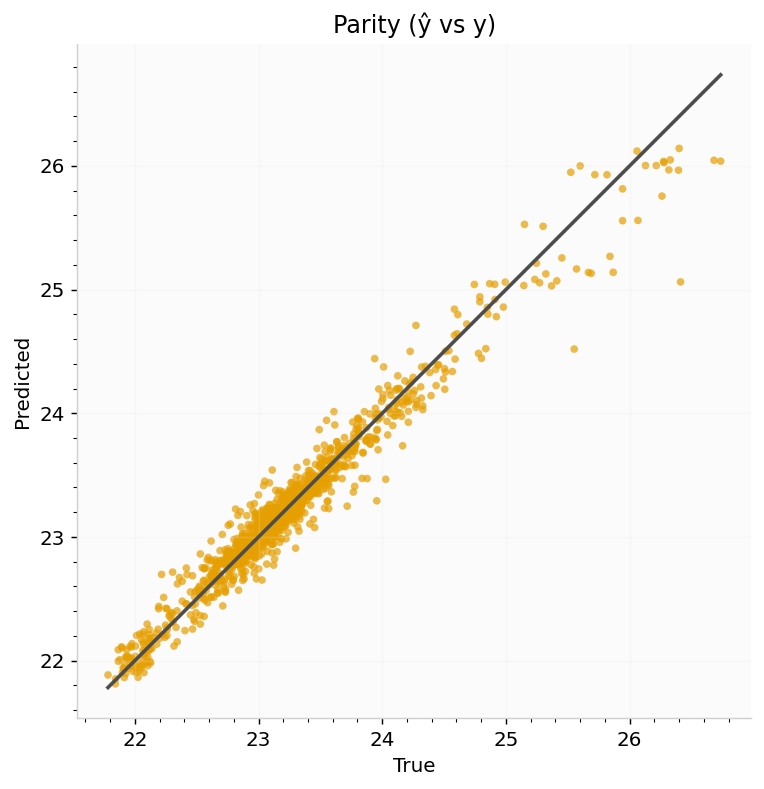

[df_4] ✓ hvac=1  Best: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 160}  (CV MAE=0.055)
           Val hvac=1: MAE=0.763  RMSE=0.998
[df_4] ✓ hvac=2  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 120}  (CV MAE=0.063)
           Val hvac=2: MAE=0.073  RMSE=0.085
[df_4] Saved RF models & features → models\df_4

[Combined ON test] metrics:


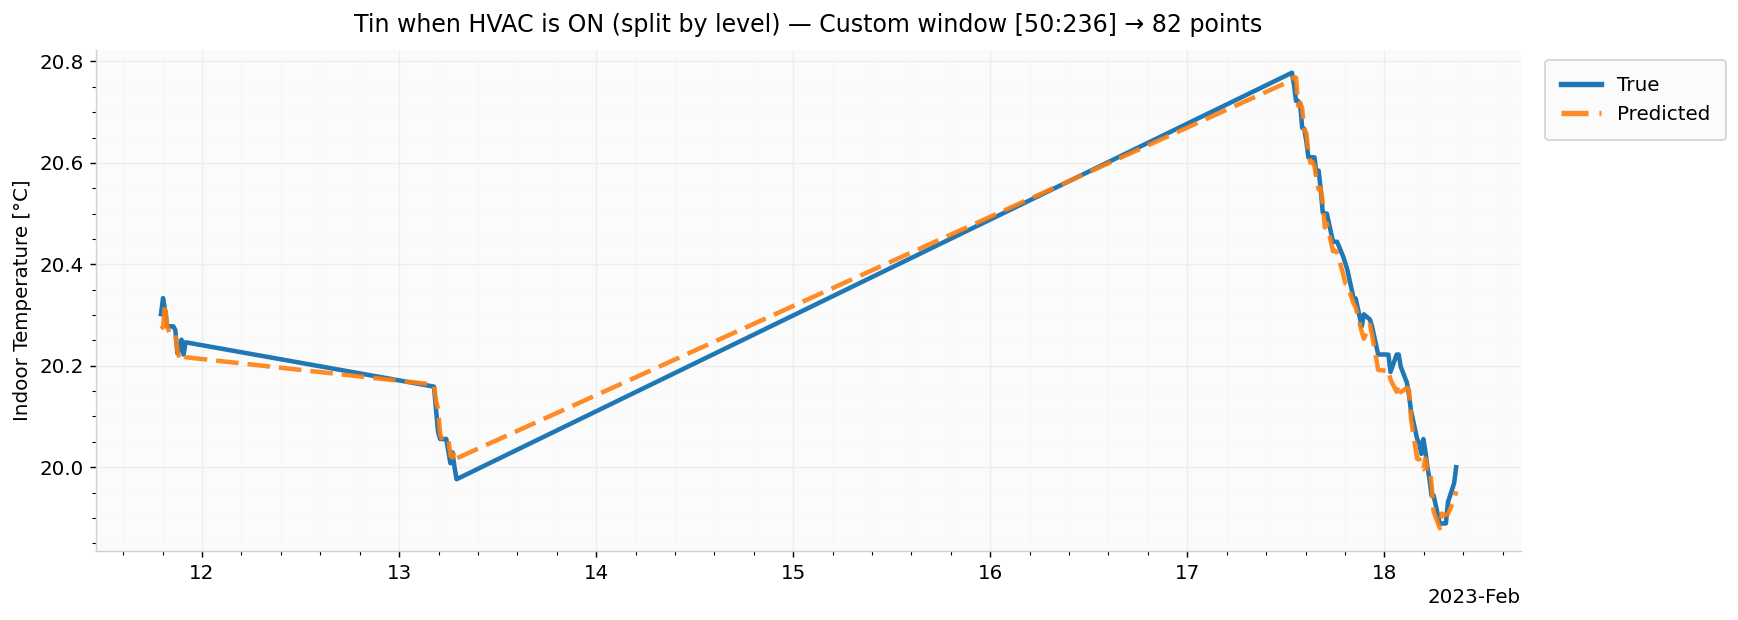

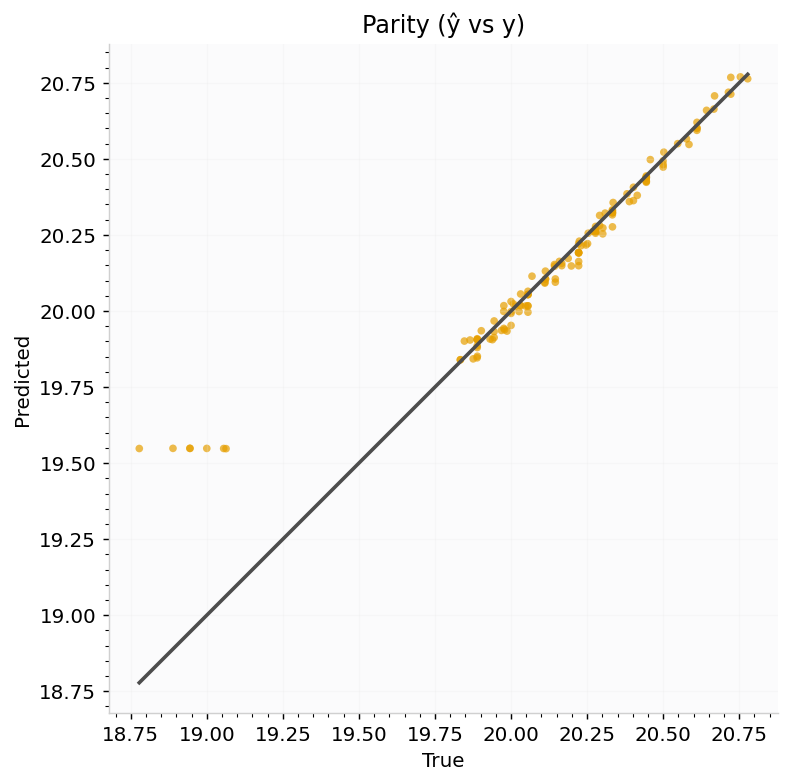

[df_5] ✓ hvac=1  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200}  (CV MAE=0.095)
           Val hvac=1: MAE=0.081  RMSE=0.101
[df_5] ✓ hvac=2  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 200}  (CV MAE=0.101)
           Val hvac=2: MAE=0.098  RMSE=0.135
[df_5] Saved RF models & features → models\df_5

[Combined ON test] metrics:


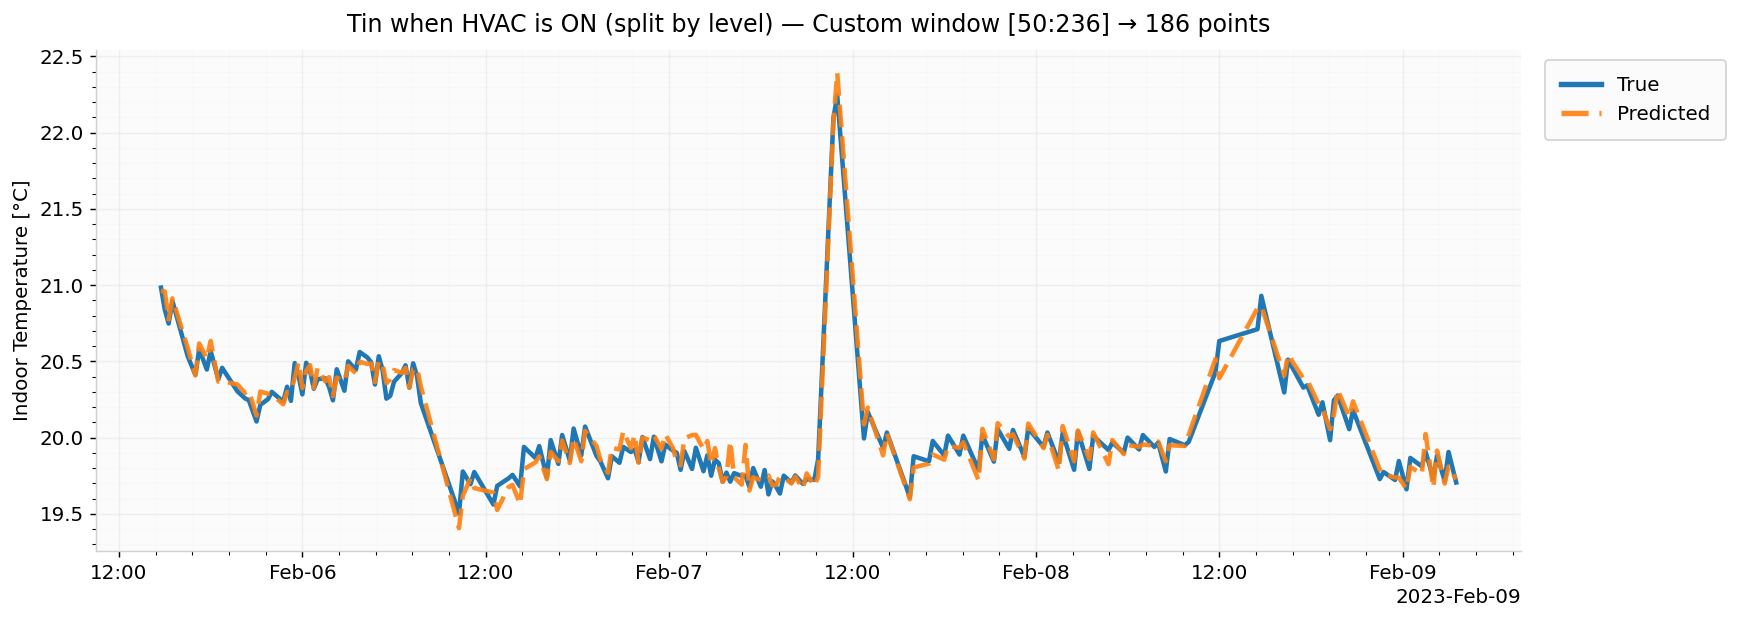

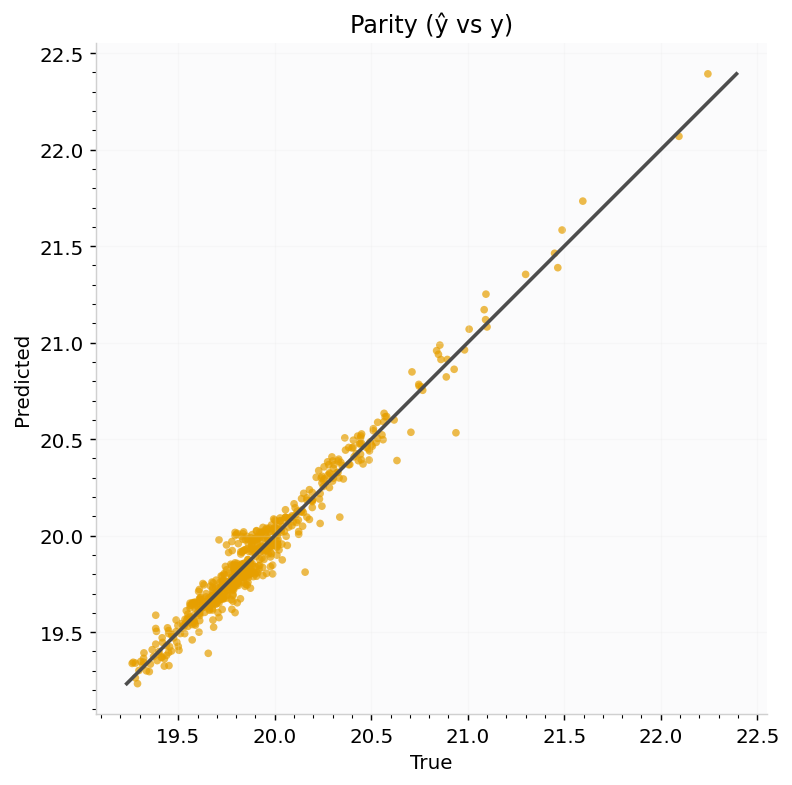

[df_6] ✓ hvac=1  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 160}  (CV MAE=0.117)
           Val hvac=1: MAE=0.062  RMSE=0.088
[df_6] ✓ hvac=2  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 160}  (CV MAE=0.142)
           Val hvac=2: MAE=0.088  RMSE=0.120
[df_6] Saved RF models & features → models\df_6

[Combined ON test] metrics:


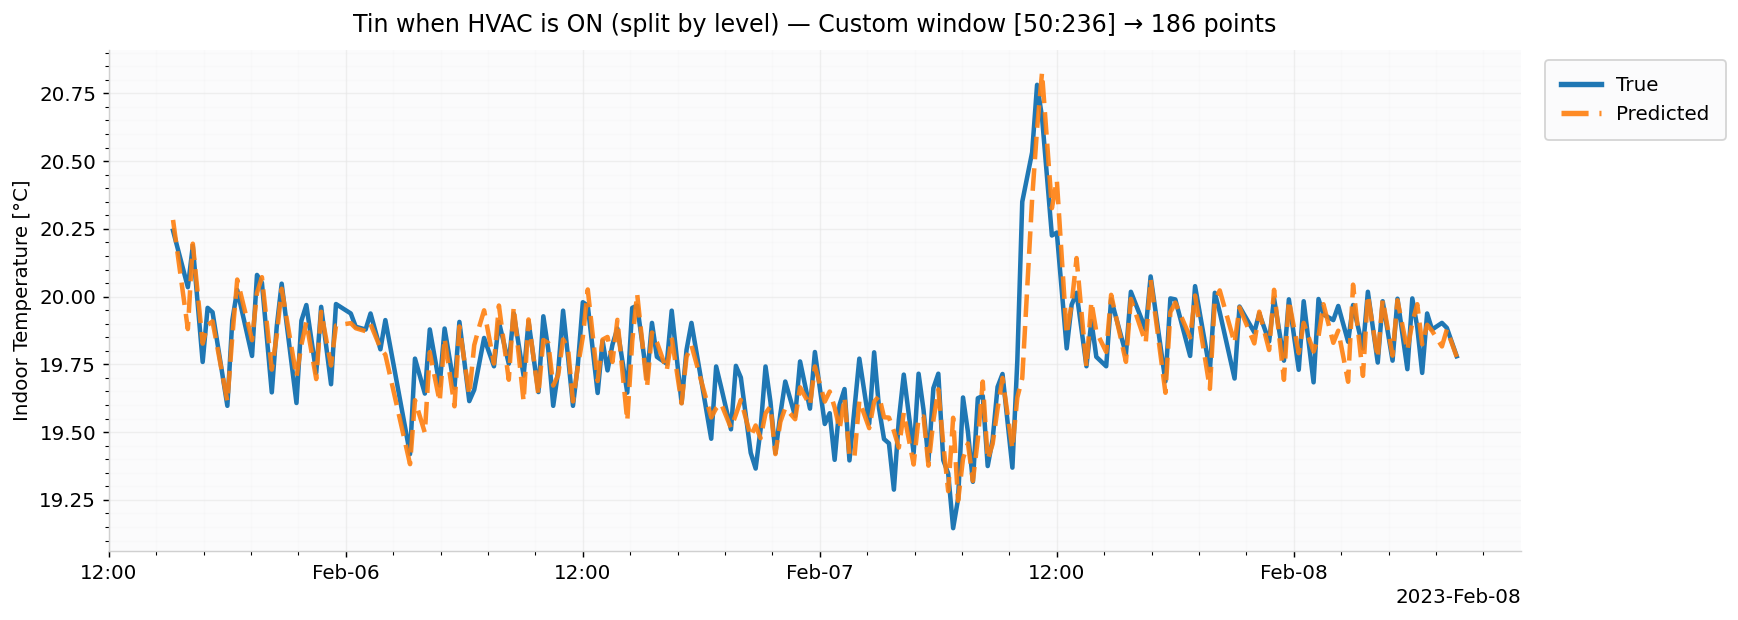

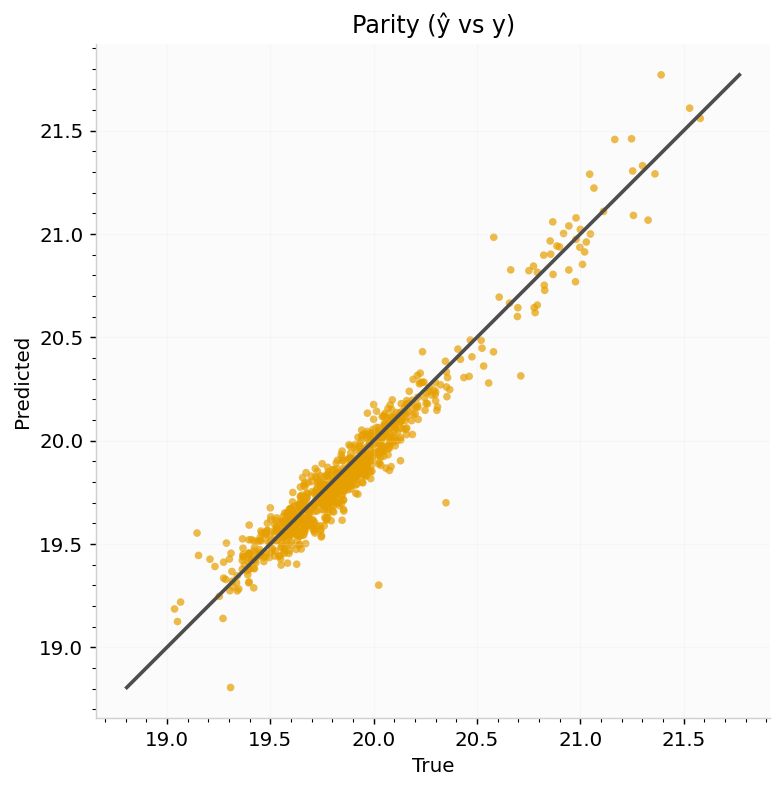

[df_7] ✓ hvac=1  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 160}  (CV MAE=0.131)
           Val hvac=1: MAE=0.080  RMSE=0.103
[df_7] ✓ hvac=2  Best: {'max_depth': 14, 'min_samples_leaf': 7, 'min_samples_split': 10, 'n_estimators': 120}  (CV MAE=0.162)
           Val hvac=2: MAE=0.124  RMSE=0.160
[df_7] Saved RF models & features → models\df_7

[Combined ON test] metrics:


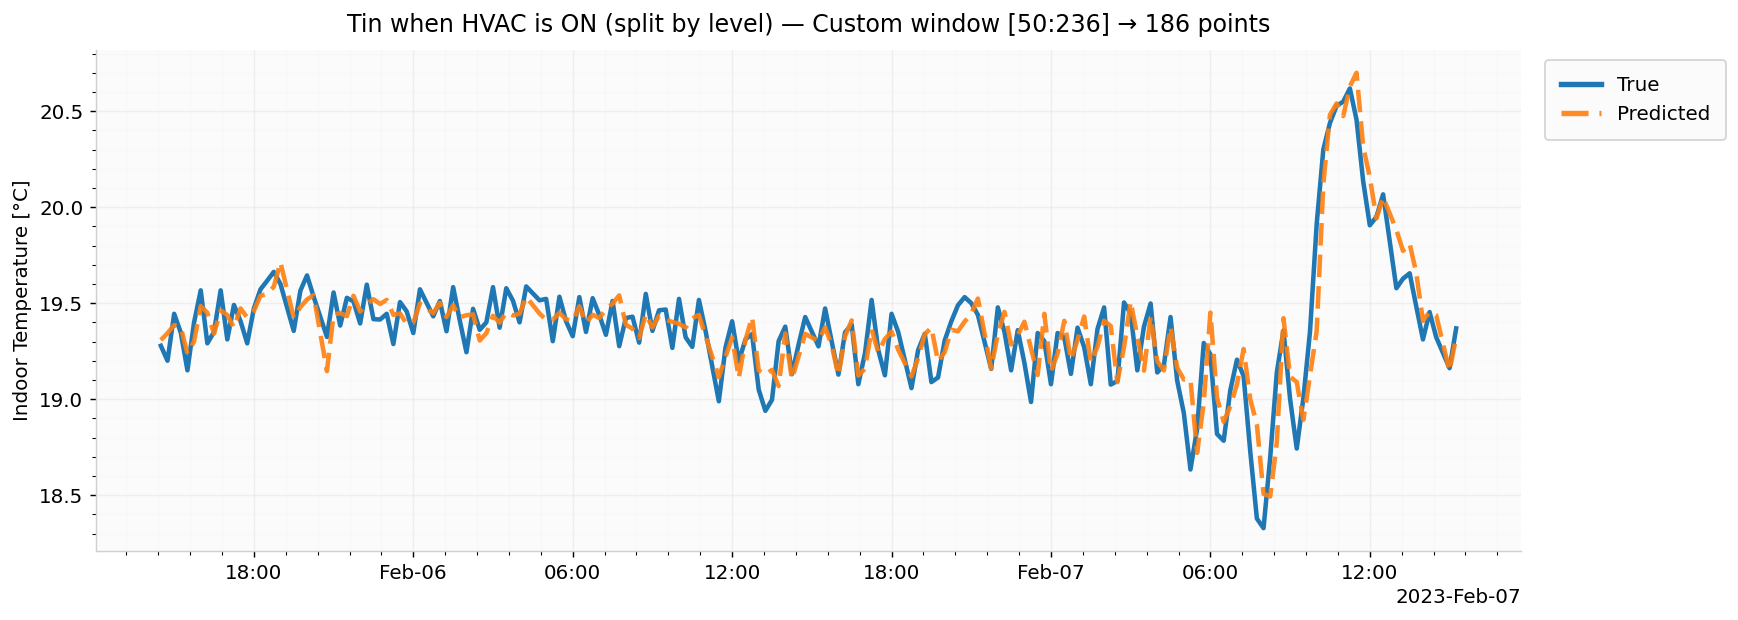

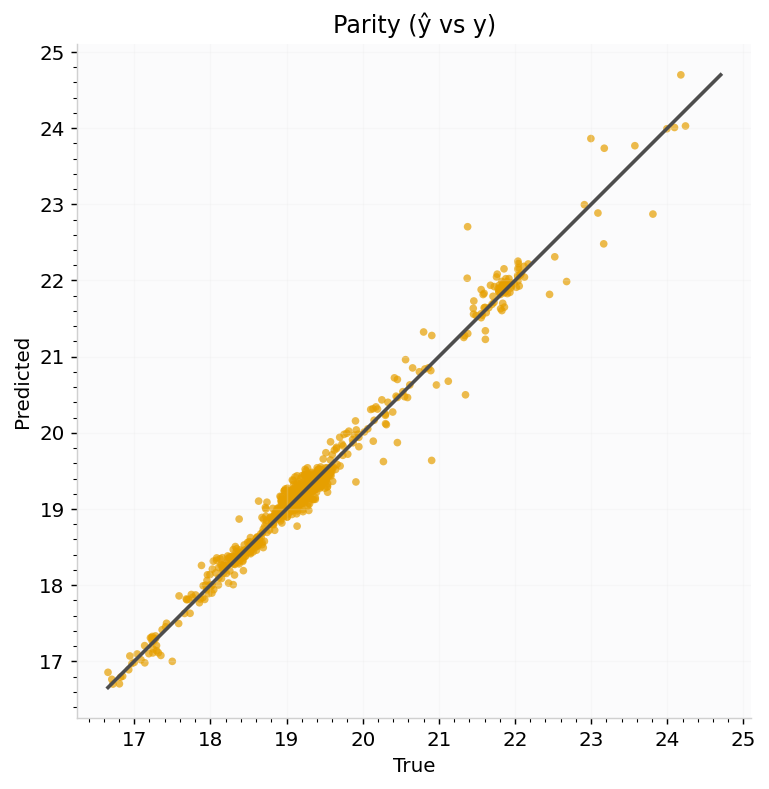

In [3]:
run_rf_hvac_on("datasets/retrofit/resampled", hvac_col="hvac_mode")

[df_0] ✓ hvac=1  Best: {'max_depth': 12, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200}  (CV MAE=0.074)
           Val hvac=1: MAE=0.061  RMSE=0.084
[df_0] ✓ hvac=2  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}  (CV MAE=0.102)
           Val hvac=2: MAE=0.092  RMSE=0.127
[df_0] Saved RF models & features → models/disaggregated\df_0

[Combined ON test] metrics:


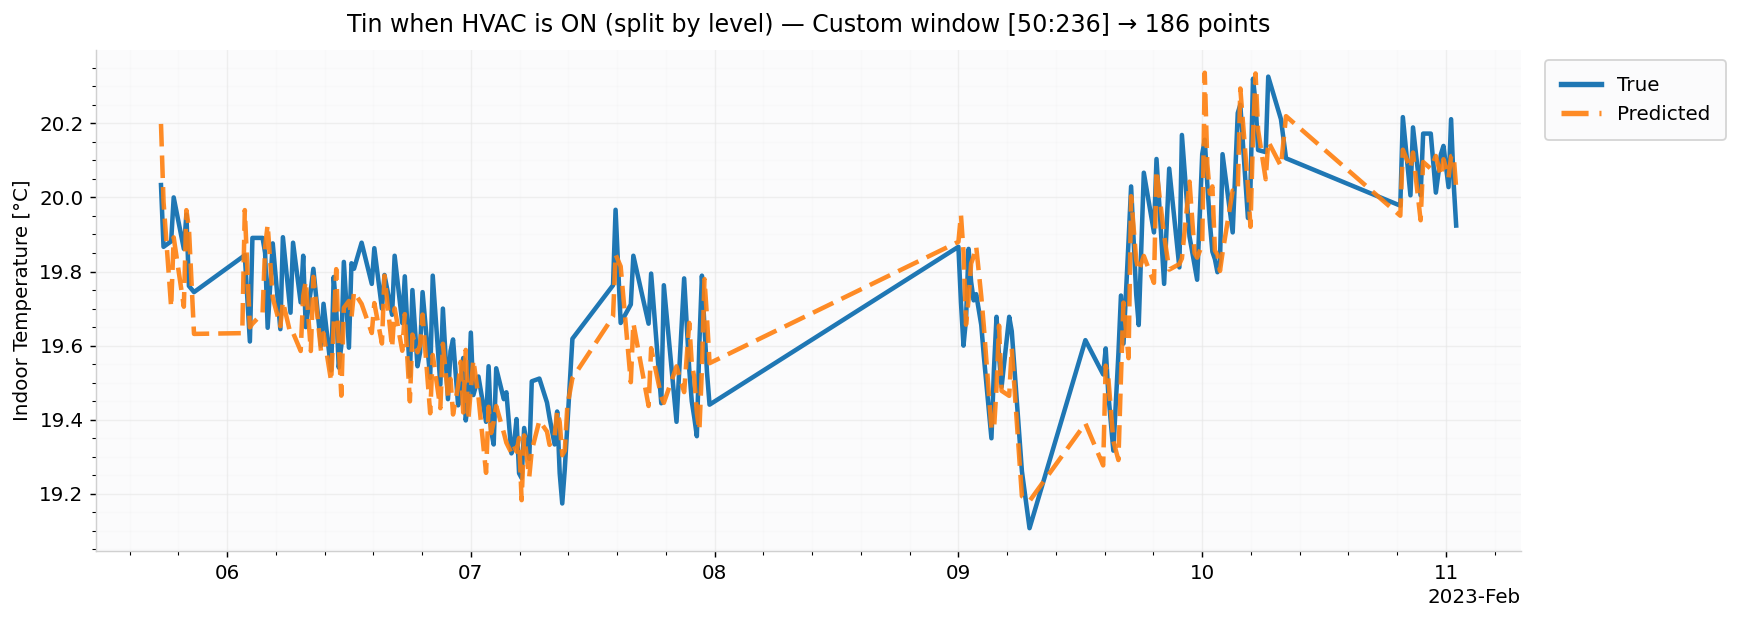

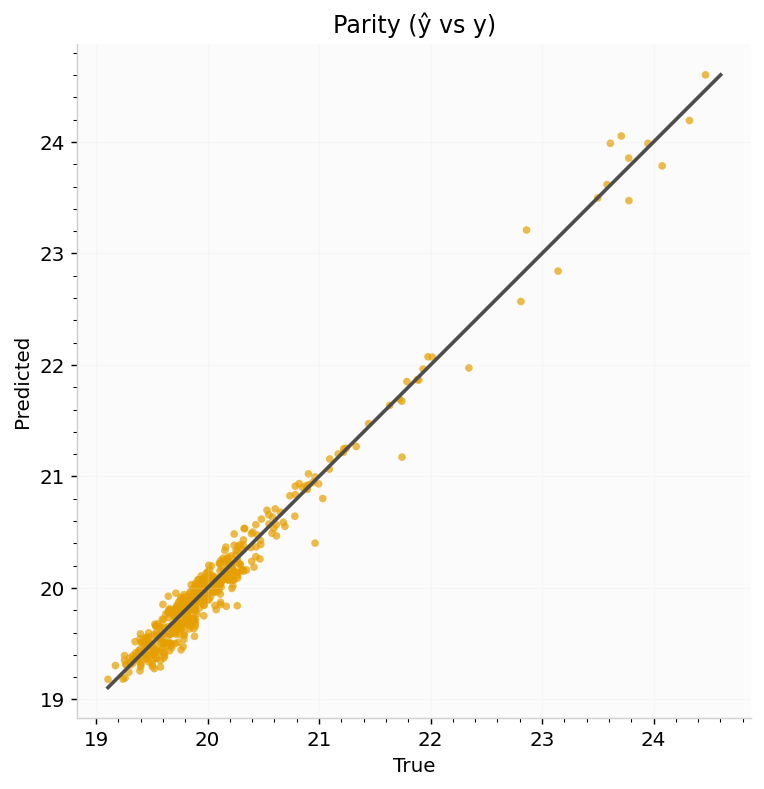

[df_1] ✓ hvac=1  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}  (CV MAE=0.179)
           Val hvac=1: MAE=0.170  RMSE=0.224
[df_1] ✓ hvac=2  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200}  (CV MAE=0.162)
           Val hvac=2: MAE=0.164  RMSE=0.212
[df_1] Saved RF models & features → models/disaggregated\df_1

[Combined ON test] metrics:


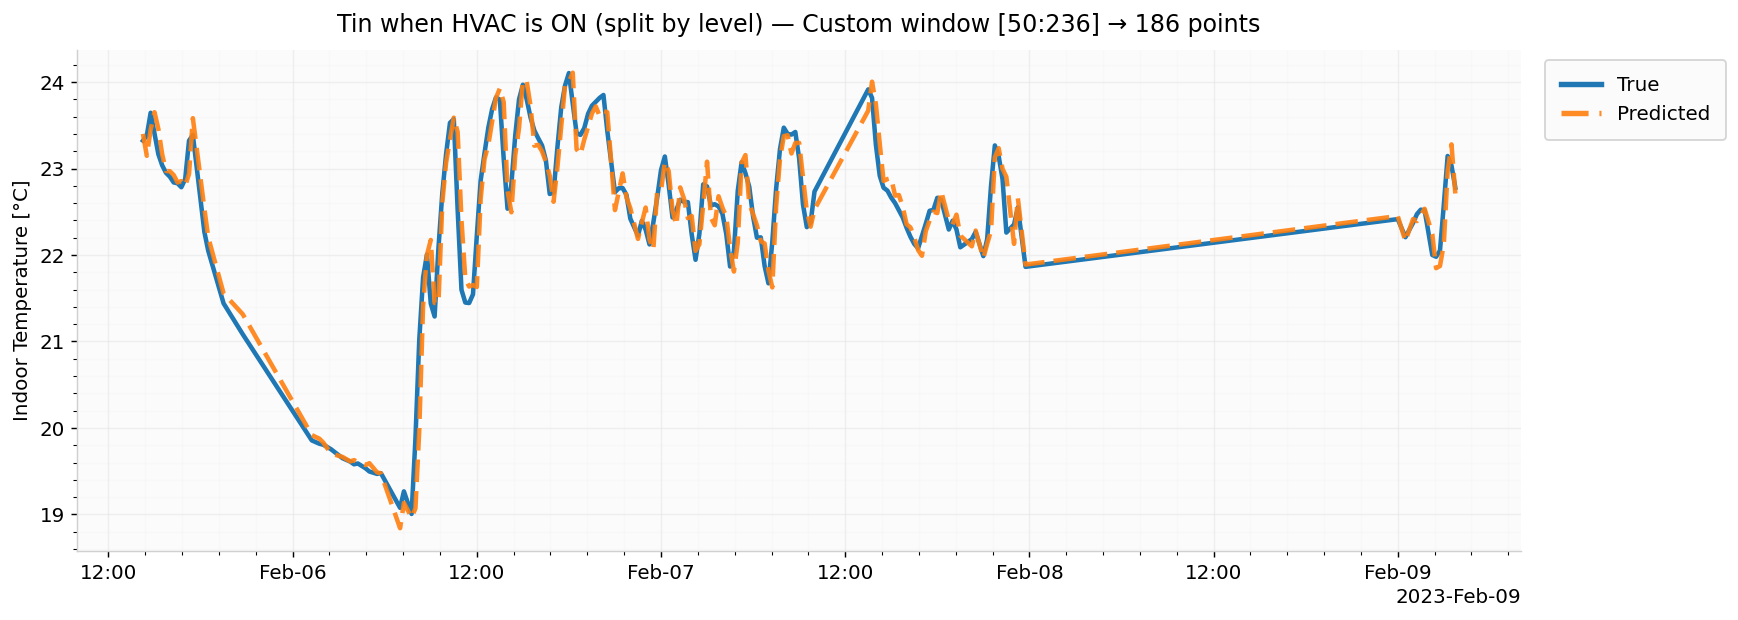

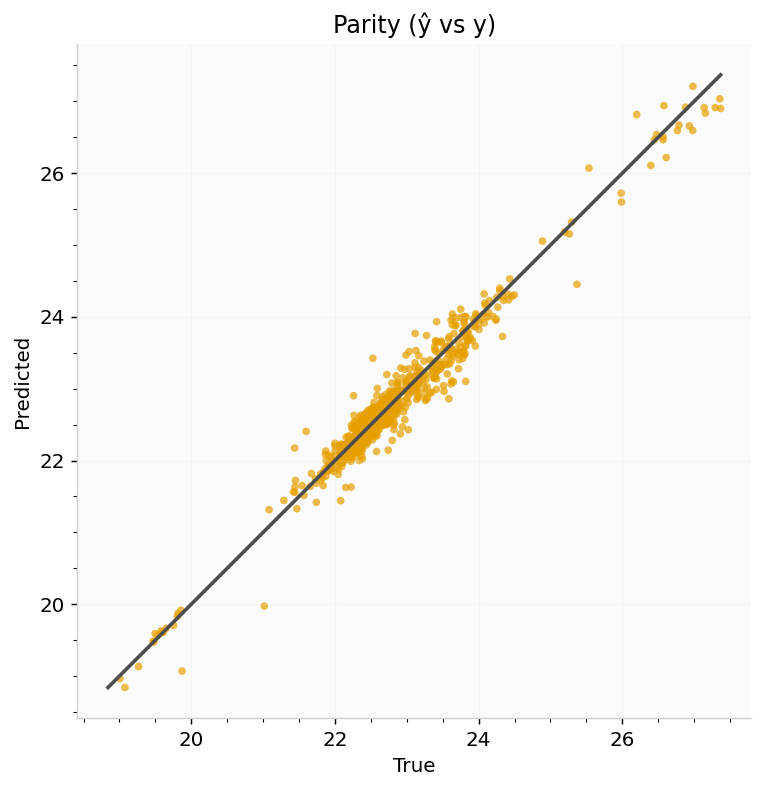

[df_2] ✓ hvac=1  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 120}  (CV MAE=0.196)
           Val hvac=1: MAE=0.099  RMSE=0.120
[df_2] ✓ hvac=2  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 160}  (CV MAE=0.088)
           Val hvac=2: MAE=0.100  RMSE=0.121
[df_2] Saved RF models & features → models/disaggregated\df_2

[Combined ON test] metrics:


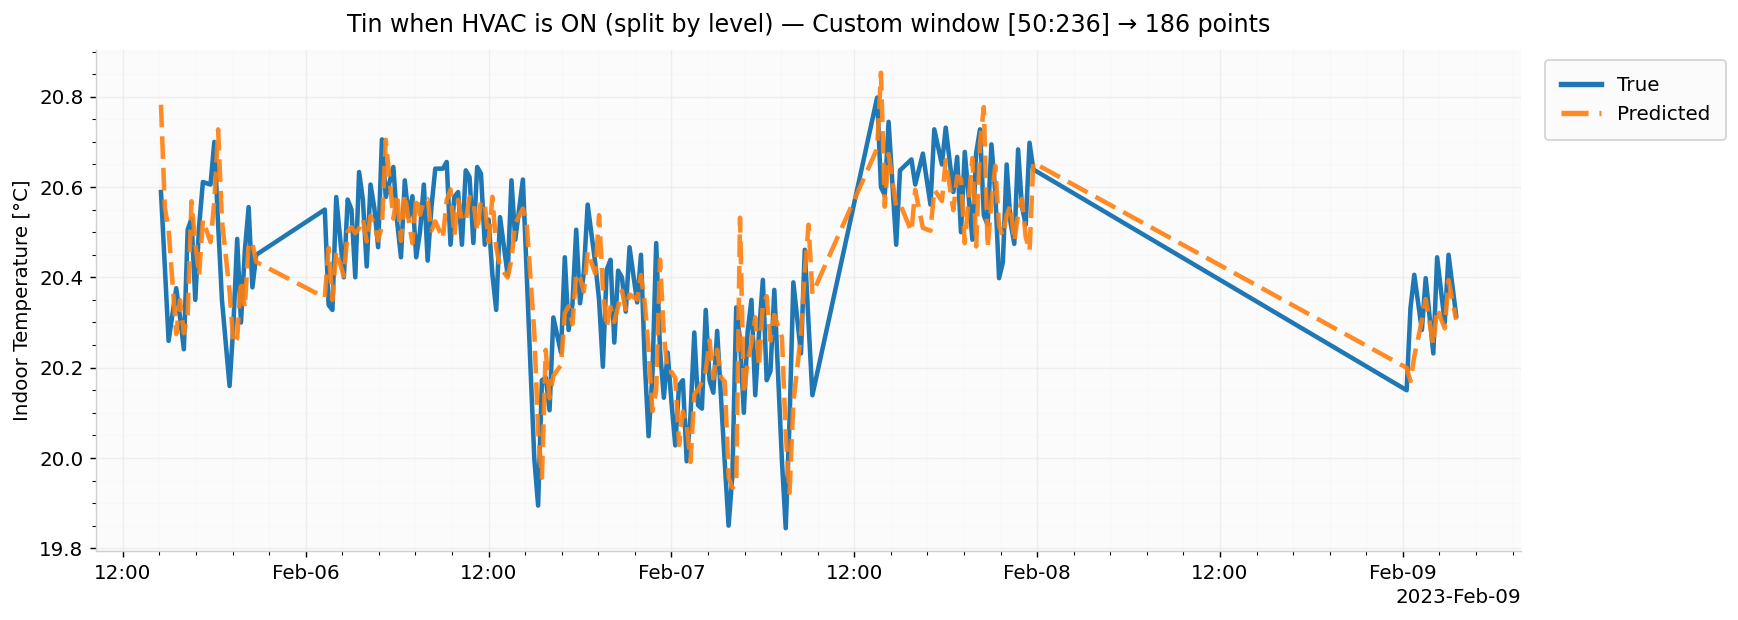

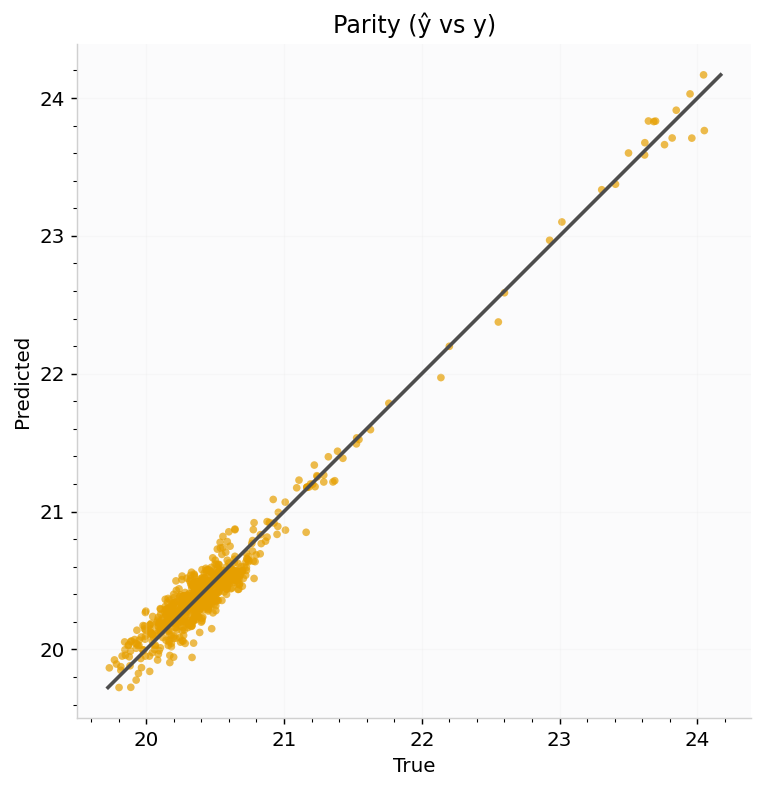

[df_3] ✓ hvac=1  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 120}  (CV MAE=0.136)
           Val hvac=1: MAE=0.210  RMSE=0.624
[df_3] ✓ hvac=2  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200}  (CV MAE=0.145)
           Val hvac=2: MAE=0.370  RMSE=0.968
[df_3] Saved RF models & features → models/disaggregated\df_3

[Combined ON test] metrics:


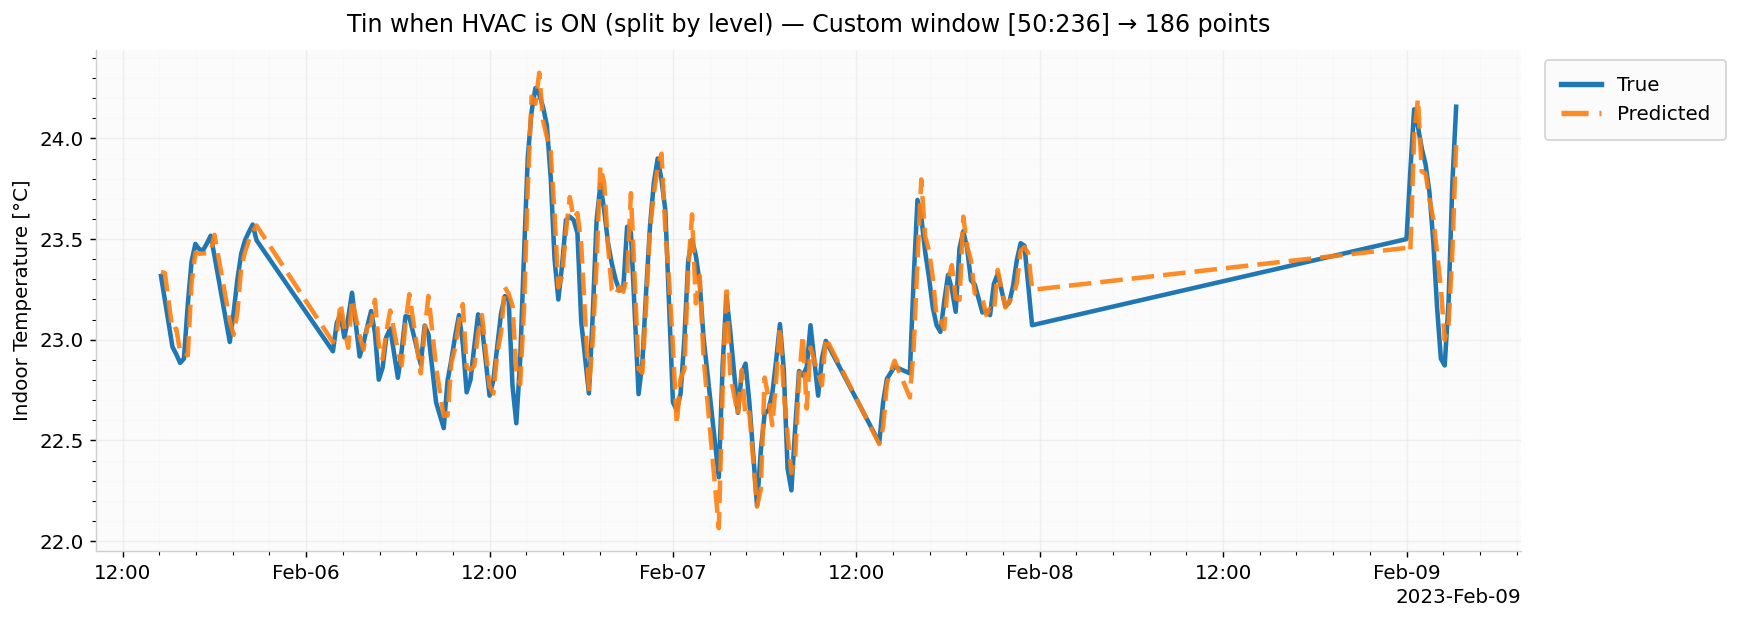

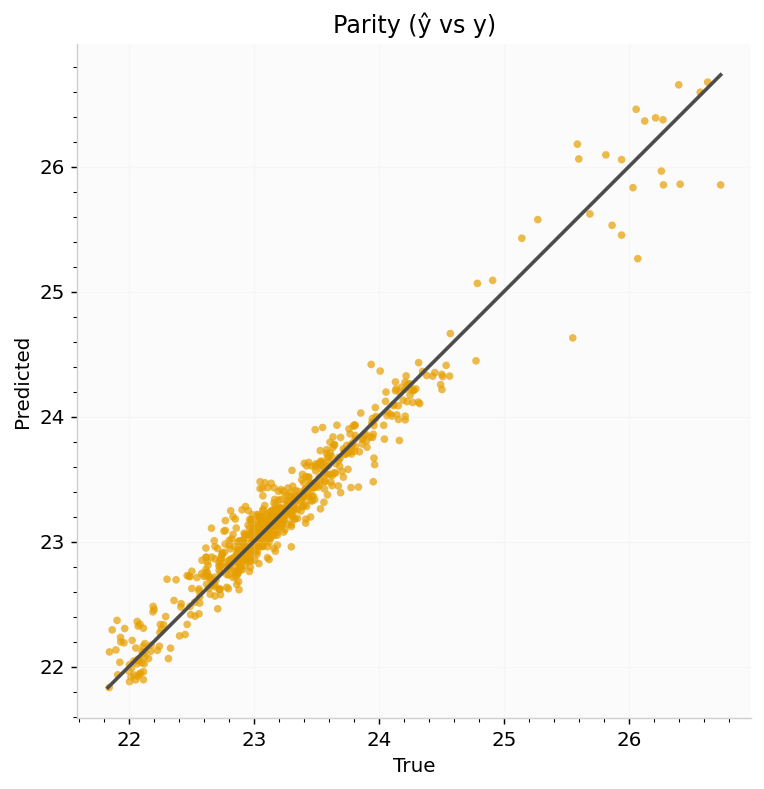

[df_4] ✓ hvac=1  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}  (CV MAE=0.081)
           Val hvac=1: MAE=0.194  RMSE=0.405
[df_4] ✓ hvac=2  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 160}  (CV MAE=0.068)
           Val hvac=2: MAE=0.173  RMSE=0.342
[df_4] Saved RF models & features → models/disaggregated\df_4

[Combined ON test] metrics:


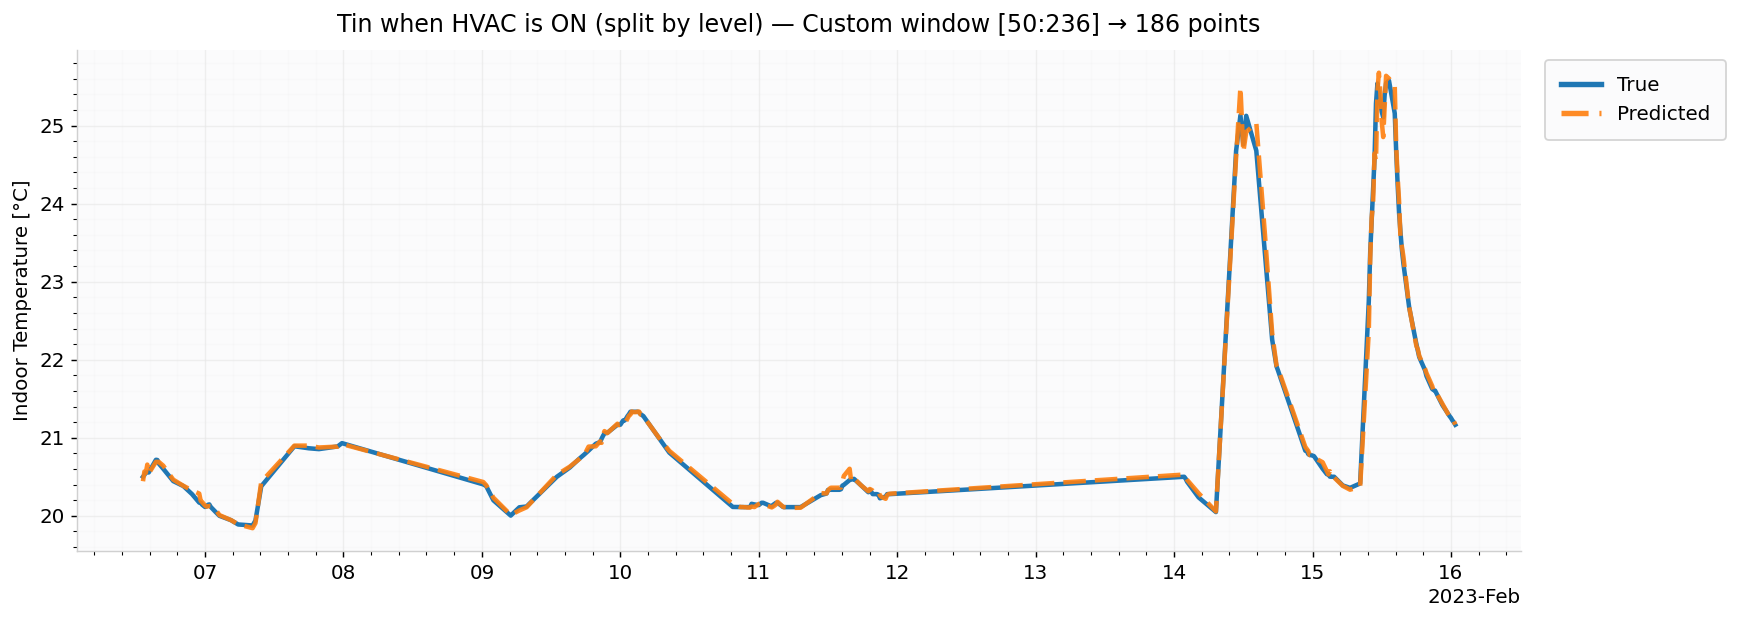

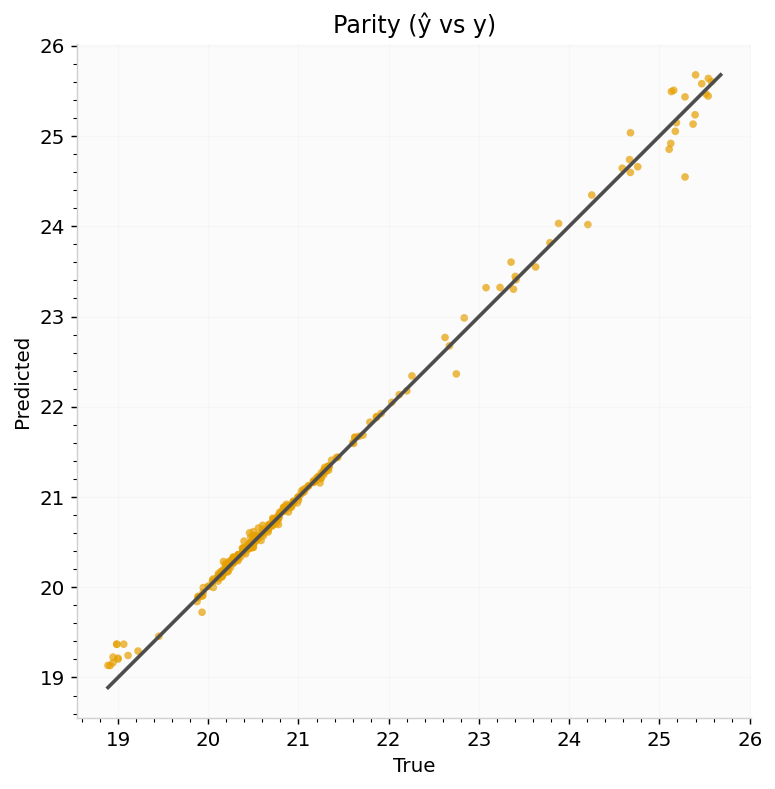

[df_5] ✓ hvac=1  Best: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 120}  (CV MAE=0.126)
           Val hvac=1: MAE=0.085  RMSE=0.109
[df_5] ✓ hvac=2  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}  (CV MAE=0.105)
           Val hvac=2: MAE=0.103  RMSE=0.139
[df_5] Saved RF models & features → models/disaggregated\df_5

[Combined ON test] metrics:


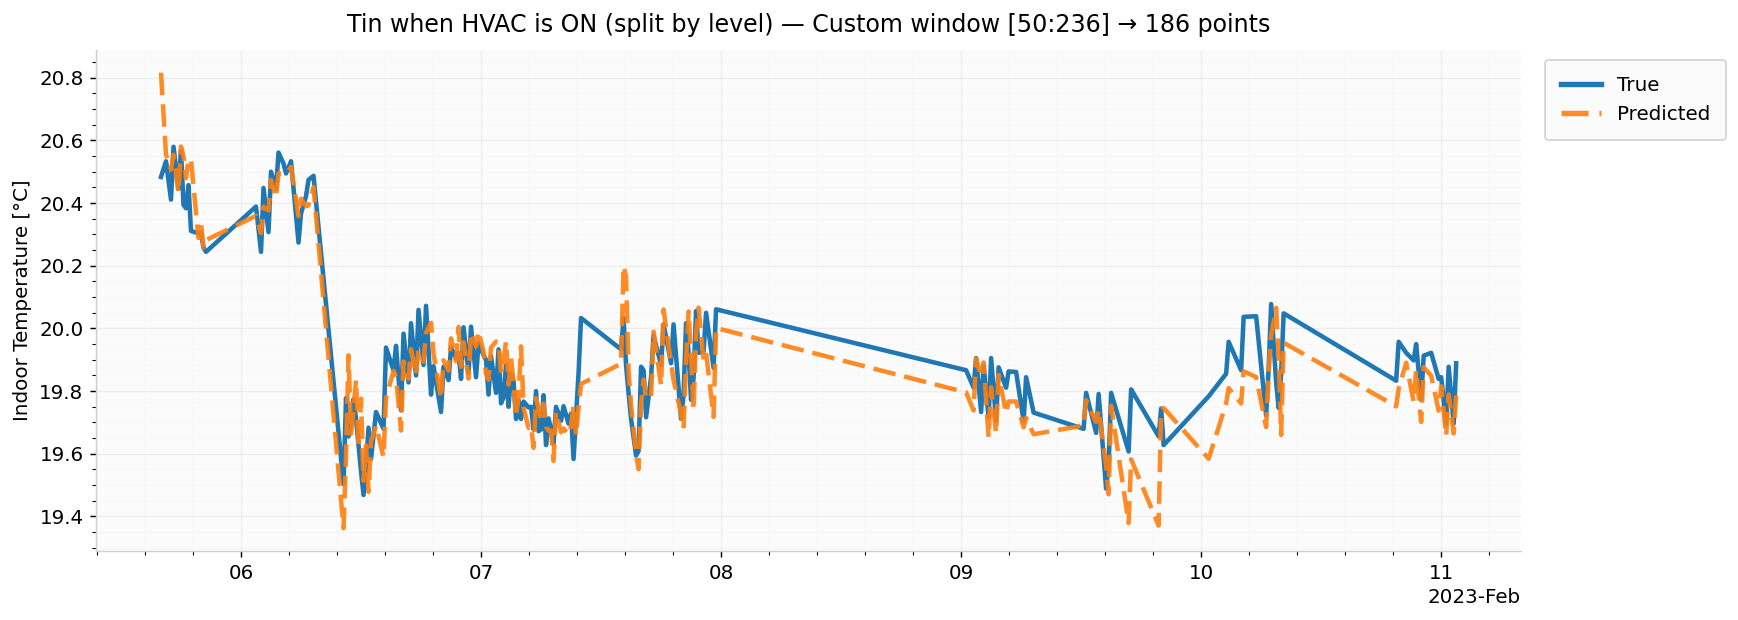

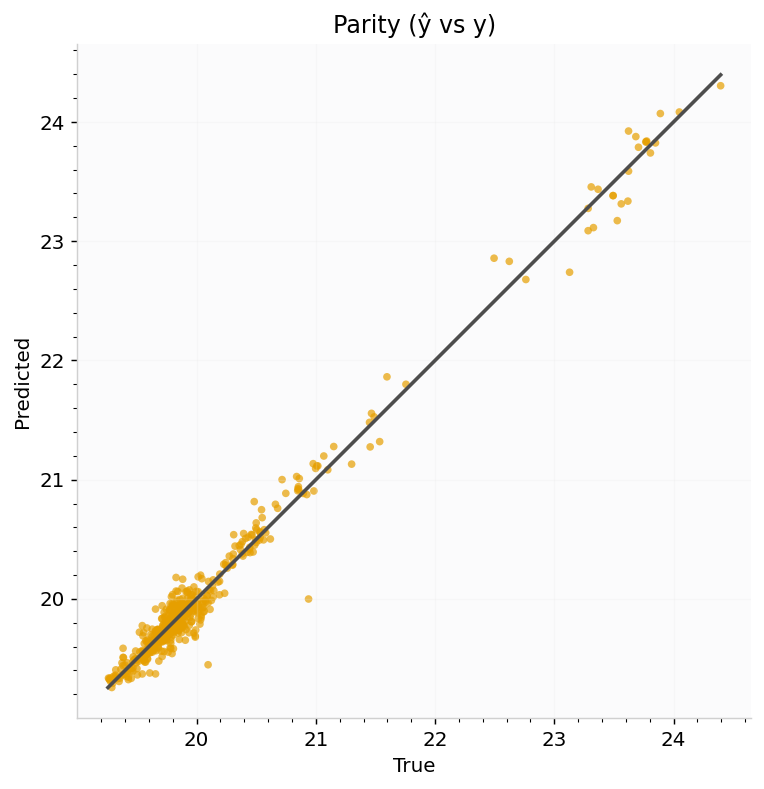

[df_6] ✓ hvac=1  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}  (CV MAE=0.143)
           Val hvac=1: MAE=0.086  RMSE=0.109
[df_6] ✓ hvac=2  Best: {'max_depth': 14, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200}  (CV MAE=0.203)
           Val hvac=2: MAE=0.092  RMSE=0.124
[df_6] Saved RF models & features → models/disaggregated\df_6

[Combined ON test] metrics:


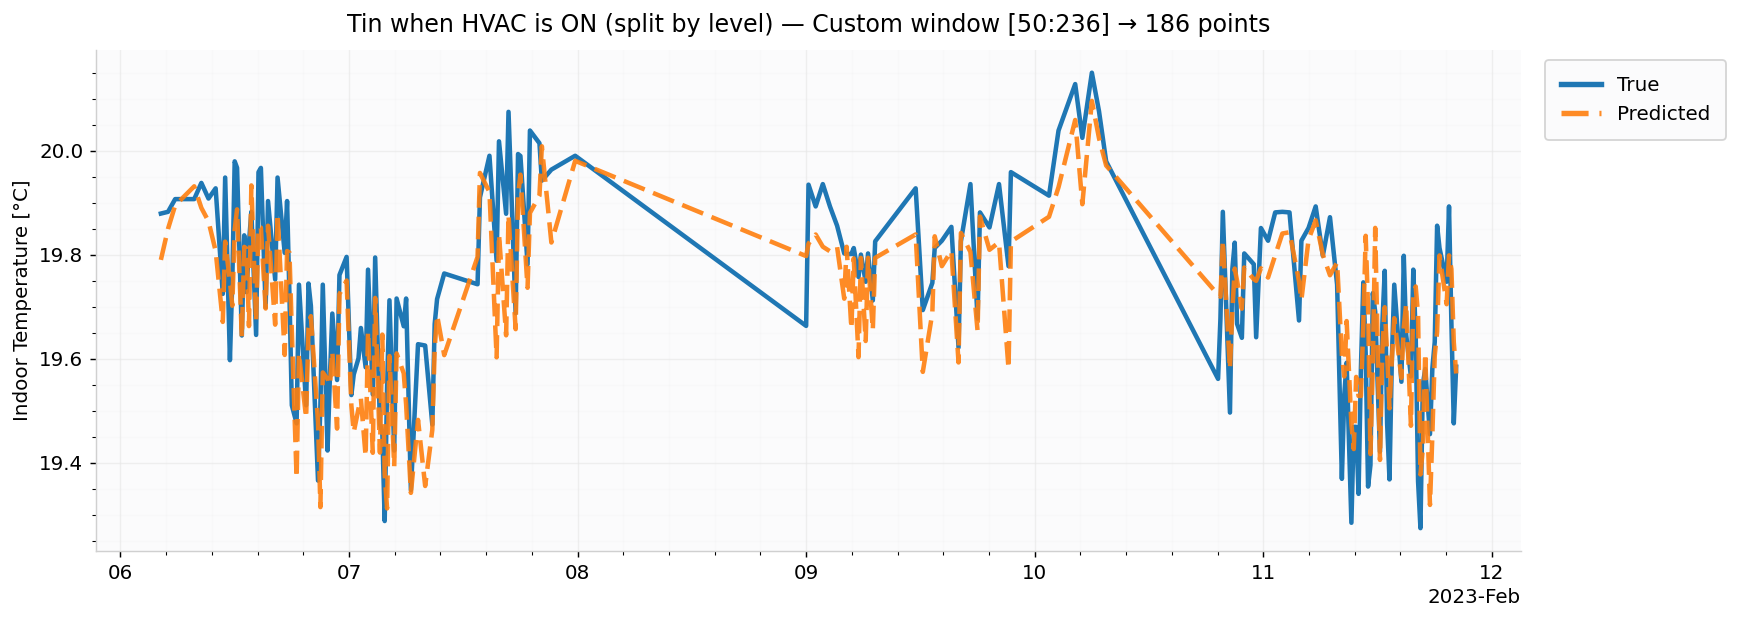

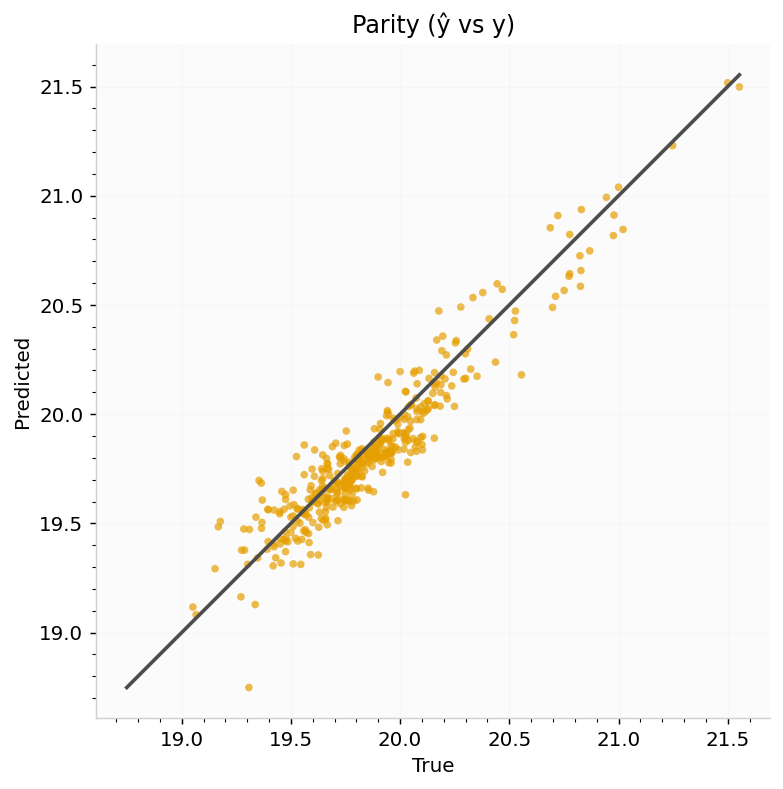

[df_7] ✓ hvac=1  Best: {'max_depth': 14, 'min_samples_leaf': 7, 'min_samples_split': 5, 'n_estimators': 200}  (CV MAE=0.166)
           Val hvac=1: MAE=0.113  RMSE=0.137
[df_7] ✓ hvac=2  Best: {'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}  (CV MAE=0.161)
           Val hvac=2: MAE=0.135  RMSE=0.168
[df_7] Saved RF models & features → models/disaggregated\df_7

[Combined ON test] metrics:


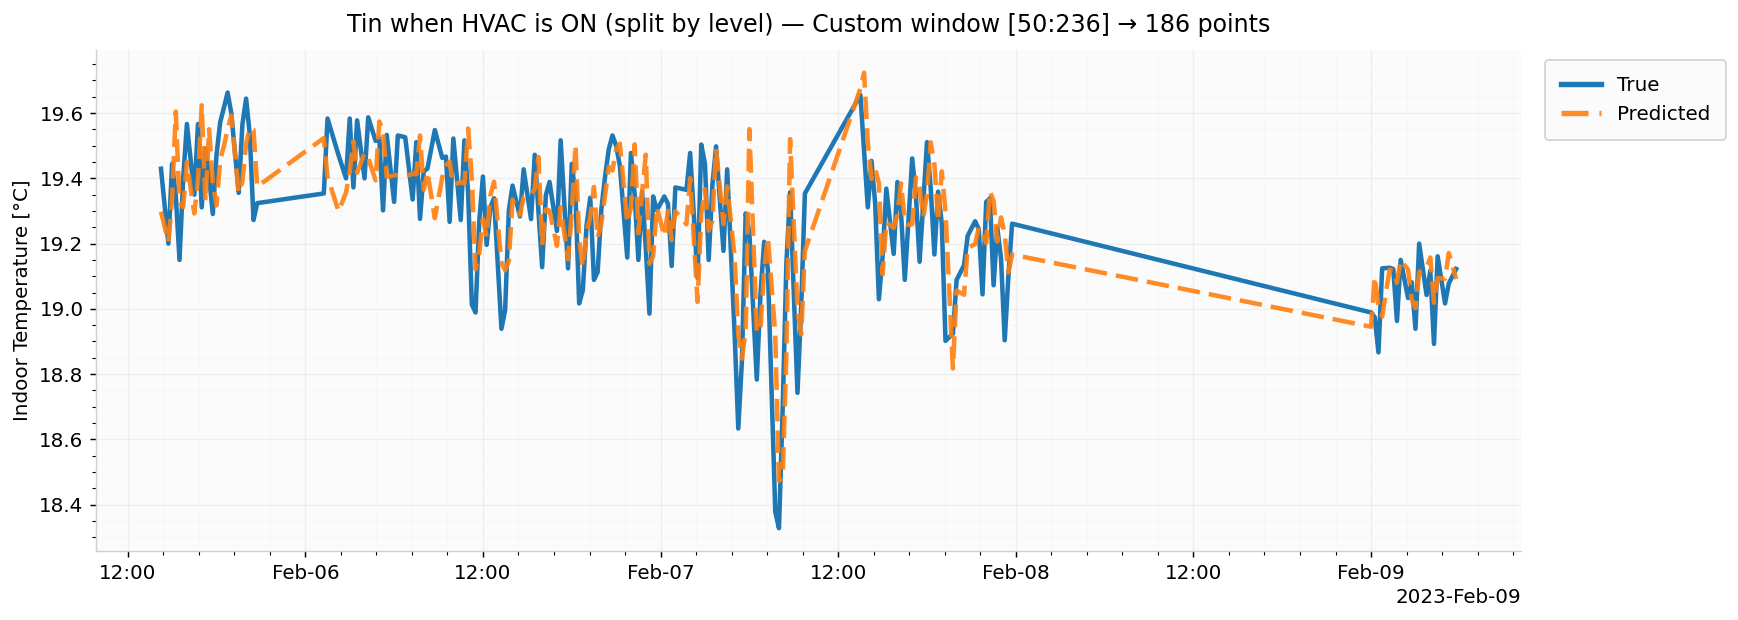

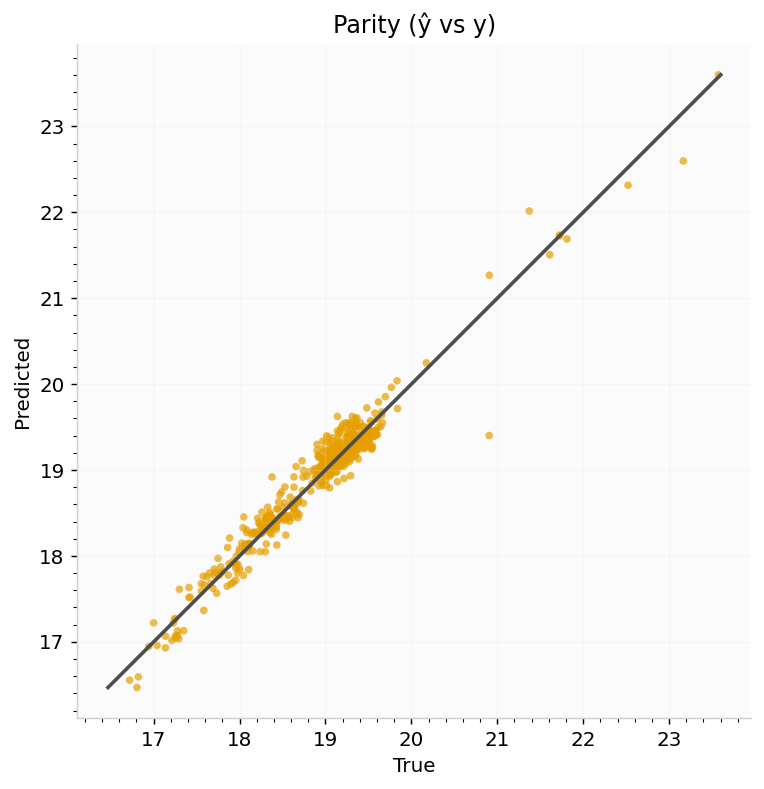

In [3]:
run_rf_hvac_on("datasets/retrofit/resampled/disaggregated", hvac_col="hvac_mode", save_root="models/disaggregated")